# Tutorial 1: Introduction to marginal likelihood estimation with bamojax

In these first steps you start computing posterior model probabilities and predictive quantities via approximate marginal likelihoods. These can be obtained in different ways. 

Feel free to explore the examples on https://github.com/UncertaintyInComplexSystems/bamojax/tree/main/bamojax/examples/model_search if you don't know how to proceed, but try to learn rather than copy-paste.

Happy averaging!

---

Load libraries, set some plotting defaults, print versions.

In [ ]:
# We manually install dependencies
!pip install numpyro==0.19.0 blackjax==1.2.5 jaxtyping

# Install bamojax, without re-evaluating its jax/jaxlib dependencies
!pip install git+https://github.com/UncertaintyInComplexSystems/bamojax#egg=bamojax --no-deps

In [2]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.random as jrnd
import jax.numpy as jnp
from jax.scipy.special import logsumexp, gammaln

import blackjax
import numpyro as npr
import numpyro.distributions as dist
import numpyro.distributions.transforms as nprb
import pandas as pd
import sys

import bamojax
from bamojax.base import Model
from bamojax.samplers import mcmc_sampler, gibbs_sampler
from bamojax.inference import MCMCInference, SMCInference
from bamojax.marginal_likelihoods.bridge_sampling import bridge_sampling
from bamojax.marginal_likelihoods.thames import thames
from bamojax.marginal_likelihoods.laplace import laplace_approximation
from bamojax.marginal_likelihoods.naive_monte_carlo import naive_monte_carlo
from bamojax.marginal_likelihoods.importance_sampling import importance_sampling

print('Python version:     ', sys.version)
print('Jax version:        ', jax.__version__)
print('BlackJax version:   ', blackjax.__version__)
print('Bamojax version:    ', bamojax.__version__)
print('Numpyro version:    ', npr.__version__)
print('Jax default backend:', jax.default_backend())
print('Jax devices:        ', jax.devices())

### plotting

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def pretty_axis(ax, fix_xaxis=True, fix_yaxis=True):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False) 
    if fix_xaxis:
        ax.spines['bottom'].set_position(('axes', -0.05))
    if fix_yaxis:
        ax.spines['left'].set_position(('axes', -0.05))

#

Python version:      3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Jax version:         0.9.2
BlackJax version:    1.2.5
Bamojax version:     0.3.13+0.ga55e0bd.dirty
Numpyro version:     0.19.0
Jax default backend: gpu
Jax devices:         [CudaDevice(id=0)]


## Some helper functions to make your life easier

In [3]:
def get_posterior_samples(key, model, num_samples):
    m = model.get_model_size()
    cold_nuts_parameters = dict(step_size=0.5, inverse_mass_matrix=0.0001*jnp.eye(m))  # these will be overriden by the window adaptation
    nuts_kernel = mcmc_sampler(model=model, mcmc_kernel=blackjax.nuts, mcmc_parameters=cold_nuts_parameters)
    engine = MCMCInference(model=model, mcmc_kernel=nuts_kernel, num_samples=num_samples, num_burn=0, num_warmup=1_000, num_thin=1)
    results = engine.run(key)
    return results['states']

#

## Load data on epileptic seizure frequencies

Our data reflects epileptic seizure counts. We first load the data $\mathbf{y}=(y_1, \ldots, y_N)$, and visualize the empirical distribution:

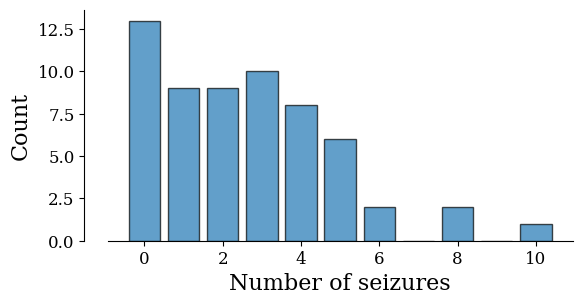

In [ ]:
y = jnp.load('data/seizure_data.npy')

N = len(y)

y_max = jnp.max(y)


plt.figure(figsize=(6, 3))
ax = plt.gca()
ax.bar(x=jnp.arange(0, y_max + 1, 1), height=jnp.histogram(y, bins=jnp.arange(0, y_max + 2, 1))[0], color='C0', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of seizures')
ax.set_ylabel('Count')
pretty_axis(ax, fix_xaxis=False);

Even for a simple data set like this, we can create many different models. Here are three that are quite natural for data with these properties (i.e., non-negative, integer data).

The first, $\mathcal{M}_P$ is a Poisson count model:
$$
\begin{align*}
    \lambda &\sim \text{Gamma}(\alpha, \beta) && \\
    y_i &\sim \text{Poisson}(\lambda) && i=1, \ldots, N \enspace,
\end{align*} 
$$ 
where we follow Hastie \& Green (2012) and set $\alpha=25$ and $\beta=10$ (note: this is completely arbitrary for this exercise and should be motivated properly in an actual study).

The Poisson distribution has a limitation: both its mean and its variance are given by $\lambda$. This means it is not possible to model data that have more variance than that. Alternativey, we can use a negative-binomial model, which has a separate variance term. This model, $\mathcal{M}_{NB}$ is given by:

$$
\begin{align*}
    \kappa &\sim \text{Gamma}(\alpha_\kappa, \beta_\kappa) && \\
    \lambda &\sim \text{Gamma}(\alpha_\lambda, \beta_\lambda) && \\    
    y_i &\sim \text{NegBin}(\lambda, \kappa) && i=1, \ldots, N \enspace,
\end{align*} 
$$ 
where we again follow Hastie \& Green (2012) and set $\alpha_\lambda, \beta_\lambda=(25, 10)$ and $\alpha_\kappa, \beta_\kappa=(1, 10)$.

Another extension of the Poisson model allows for more zeros than we typically expect in a Poisson model. This model, $\mathcal{M}_{ZIP}$, is known as the 'zero-inflated Poisson', and is given by:
\begin{align*}
    \pi &\sim \text{Beta}(\alpha_\pi, \beta_\pi) && \\
    \lambda &\sim \text{Gamma}(\alpha_\lambda, \beta_\lambda) && \\    
    y_i &\sim \text{ZIP}(\lambda, \pi) && i=1, \ldots, N \enspace,
\end{align*} 
where we say we are agnostic about the masking probability $\pi$ (with this probability the observation is zero, regardless of $\lambda$).

Here is the bamojax code to implement these models:

In [117]:
def construct_poisson_model(observations) -> Model:
    model = Model('Poisson')
    rate_node = model.add_node('lam', distribution=dist.Gamma(concentration=25, rate=10))
    _ = model.add_node('y', observations=observations, parents=dict(rate=rate_node), distribution=dist.Poisson)
    return model

#
def construct_negative_binomial_model(observations) -> Model:
    # Note: Hastie & Green, Wikipedia, and TFD all have their own parametrizations of the negative binomial.
    # The transformation below ensures we use the one by H&G for consistency.
    def negbin_link_fn(rate, dispersion):
        p = rate / (rate + 1 / dispersion)
        r = 1 / dispersion
        return dict(probs=p, total_count=r)

    #

    model = Model('Negative binomial')
    rate_node = model.add_node('lam', distribution=dist.Gamma(concentration=25, rate=10)) 
    dispersion_node = model.add_node('kappa', distribution=dist.Gamma(concentration=1, rate=10))  
    _ = model.add_node('y', observations=observations, parents=dict(rate=rate_node, dispersion=dispersion_node), distribution=dist.NegativeBinomialProbs, link_fn=negbin_link_fn)
    return model

#
def construct_zero_inflated_poisson_model(observations) -> Model:
    model = Model('Zero-inflated Poisson')
    rate_node = model.add_node('lam', distribution=dist.Gamma(concentration=25, rate=10)) 
    gate_node = model.add_node('pi', distribution=dist.Beta(concentration1=1, concentration0=1))  
    _ = model.add_node('y', observations=observations, parents=dict(rate=rate_node, gate=gate_node), distribution=dist.ZeroInflatedPoisson)
    return model

poisson_model = construct_poisson_model(y)
negbin_model = construct_negative_binomial_model(y)
zipoisson_model = construct_zero_inflated_poisson_model(y)

models = [poisson_model, negbin_model, zipoisson_model]
num_models = len(models)

### Question 0: Plot the prior predictive distributions

In case of simple models with a one-dimensional prediction, it is a good habit to visualize the prior predictive distributions. Make a bar chart in the same dimensions as the data visualization plot of the **prior predictions** - you can get these via `model.sample_prior_predictive(...)` (see Tutorial 0 for JAX `keys` and `vmaps` to make this efficient!).

Do you see particular features in these predictive distributions that we also observed in the actual data?

### Question 1: Find the posterior model probabilities of these three models

You now have the model definition for the $M=3$ competing models. Use the bamojax tools to find the posterior model probabilities (PMPs) of each. To do so, start by the estimating the log marginal likelihoods $L_P = \log p(\mathbf{y}\mid \mathcal{M}_P)$, $L_{NB} = \log p(\mathbf{y}\mid \mathcal{M}_{NB})$, and $L_{ZIP}= \log p(\mathbf{y}\mid \mathcal{M}_{ZIP})$.

From the log marginal likelihoods $L$ you can compute the posterior model probabilities using

$$
  PMP_i = \exp(L_i - \log \sum_{j=1}^M \exp(L_j))
$$

To implement this, you can use the `logsumexp` function.

You can use the following ways of computing the marginal likelihood:
- *Naive Monte Carlo*
  - Approximates the marginal likelihood integral by the sum $p(D \mid \mathcal{M}) \approx \frac{1}{M}\sum_{i=1}^M p\left(D\mid \theta^{(i)},\mathcal{M}\right)$ with $\theta^{(i)}\sim p(\theta \mid \mathcal{M})$. This is mathematically correct but fundamentally ill-equiped for models with more than a trivial number of parameters. Still works for the examples here though!
  - In a way it is the gold standard - if we run it long enough, we know we'll find what we need, as it is unbiased.
- *Importance sampling*
  - Requires an additional importance density $g(\theta)$ from which we can sample easily.
- *The THAMES estimator*
  - Requires posterior samples, which we can get via e.g. NUTS HMC.
  - See [Metodiev et al.](https://projecteuclid.org/journals/bayesian-analysis/advance-publication/Easily-Computed-Marginal-Likelihoods-from-Posterior-Simulation-Using-the-THAMES/10.1214/24-BA1422.full).
- *Bridge sampling*
  - Requires posterior samples, which we can get via e.g. NUTS HMC, and a collection of bijectors in case there are constrained variables (here, $\lambda$ and $\kappa$ are non-negative for example).
  - One of the best approaches to date, especially its warped extensions.
  - See [Gronau et al.](https://www.sciencedirect.com/science/article/pii/S0022249617300640).
- *The Laplace approximation*
  - Approximates the posterior by a Gaussian.
  - Requires you indicate the bounds of the variables.
  - Requires very little else, but assumes the posterior is approximately Gaussian, which is rarely true.
  - Is a bit brittle; one can best do the Laplace approximation to transformed versions of models, but that is beyond the scope of today.
- *Sequential Monte Carlo*
  - Obtains both posterior samples and a marginal likelihood approximation simultaneously.
  - Requires that you define an MCMC kernel; MCMC is part of the SMC routine.
  - Is highly efficient on GPU as it is inherently parallel. Slow on CPU.
  - See [my tutorial paper](https://pubmed.ncbi.nlm.nih.gov/40138056/).

Compare the results of at least three approaches. Also compare results of different random seeds (`keys`). Which methods seem consistent and which seem to have trouble?

Note that some approaches, like bridge sampling and THAMES, require you to first obtain samples from the posteriors $p(\theta, \mid \mathbf{y}, \mathcal{M})$. Use the helper function `get_posterior_samples` up top to do this (you can also do this in many other ways, but this will quickly get you going).

Also, from the Bayes factor, compute the PMPs, assuming a flat model prior, so that $p(\mathcal{M}_P)=p(\mathcal{M}_{NB})=p(\mathcal{M}_{ZIP})=1/3$. Which model is the most likely?

### Question 2: Create the Bayesian model averaged distribution of the posterior predictive of $\mathbf{y}$

You now have the posterior model probabilities $p(\mathcal{M}_P\mid \mathbf{y})$, $p(\mathcal{M}_{NB}\mid \mathbf{y})$, and $p(\mathcal{M}_{ZIP}\mid \mathbf{y})$. Each of these model can be used to create **posterior predictive samples**. This requires that you first collect $S$ samples from each model's posterior (through inference), and then you use `model.sample_posterior_predictive`.

Create four histograms / bar charts in one plot, containing the posterior predictive samples for either model, as well as the BMA. The latter you can obtain by selecting $S_i$ samples from each posterior, where $S_i=[S\cdot PMP_i]$ (so if you want to show 1000 samples in total, and your PMPs are [0.3, 0.5, 0.2], then you use 300 samples for the first model, 500 for the second, and 200 for the last).

(You can use e.g. `jrnd.choice(...)` to select a random subset of samples from any of the models.)

### Question 3

Use the sampled posterior predictions of the different models, as well as the BMA, to predict the expected number of seizures per week (i.e., the mean of the samples).

Similarly, compute the posterior probability of finding exactly zero seizures.

In this simple example, the difference between the models' predictions isn't so massive, but it illustrates how to use the `bamojax` tools for BMA. In the next tutorial, we'll see that the difference between selecting the top model and the BMA can be qualitative!